## Importing Libraries and Datasets

In [1]:
!pip install pandas scikit-learn
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv("../ml/Text_Processed_Dataset.csv")
df.shape

(5169, 6)

In [4]:
df.head(3)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...


------

## Text Vectorization

In [5]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features=3000)

In [6]:

df.dropna(subset=['transformed_text'], inplace=True)


df['transformed_text'] = df['transformed_text'].fillna('')


X = tf.fit_transform(df['transformed_text']).toarray()

In [7]:
X.shape

(5160, 3000)

In [8]:
y = df['target'].values

----

## Train Test Split

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

-----

## Naive Bayes Model Trainng

In [11]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

**GaussianNB**

In [12]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.875968992248062
[[799 107]
 [ 21 105]]
0.49528301886792453


**MultinomialNB**

In [13]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738372093023255
[[906   0]
 [ 27  99]]
1.0


**BernoulliNB**

In [14]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9854651162790697
[[905   1]
 [ 14 112]]
0.9911504424778761


-------

## Other Machine Learning Model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [16]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)


In [17]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
}

In [18]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [23]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9757751937984496
Precision -  0.9809523809523809
For  KN
Accuracy -  0.9244186046511628
Precision -  1.0
For  NB
Accuracy -  0.9738372093023255
Precision -  1.0
For  DT
Accuracy -  0.938953488372093
Precision -  0.794392523364486
For  LR
Accuracy -  0.9593023255813954
Precision -  0.9468085106382979


/Users/home/Documents/Projects/Email & SMS classifier/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/home/Documents/Projects/Email & SMS classifier/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9748062015503876
Precision -  0.9901960784313726
For  AdaBoost
Accuracy -  0.9205426356589147
Precision -  0.775
For  BgC
Accuracy -  0.9534883720930233
Precision -  0.8145161290322581
For  ETC
Accuracy -  0.9748062015503876
Precision -  0.9807692307692307
For  GBDT
Accuracy -  0.9534883720930233
Precision -  0.9148936170212766


In [24]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.924419,1.000000
2,NB,0.973837,1.000000
5,RF,0.974806,0.990196
0,SVC,0.975775,0.980952
8,ETC,0.974806,0.980769
4,LR,0.959302,0.946809
9,GBDT,0.953488,0.914894
7,BgC,0.953488,0.814516
3,DT,0.938953,0.794393
6,AdaBoost,0.920543,0.775000


In [25]:
performance_df = pd.melt(performance_df, id_vars = "Algorithm")
performance_df

,Algorithm,variable,value
0,KN,Accuracy,0.924419
1,NB,Accuracy,0.973837
2,RF,Accuracy,0.974806
3,SVC,Accuracy,0.975775
4,ETC,Accuracy,0.974806
5,LR,Accuracy,0.959302
6,GBDT,Accuracy,0.953488
7,BgC,Accuracy,0.953488
8,DT,Accuracy,0.938953
9,AdaBoost,Accuracy,0.920543


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

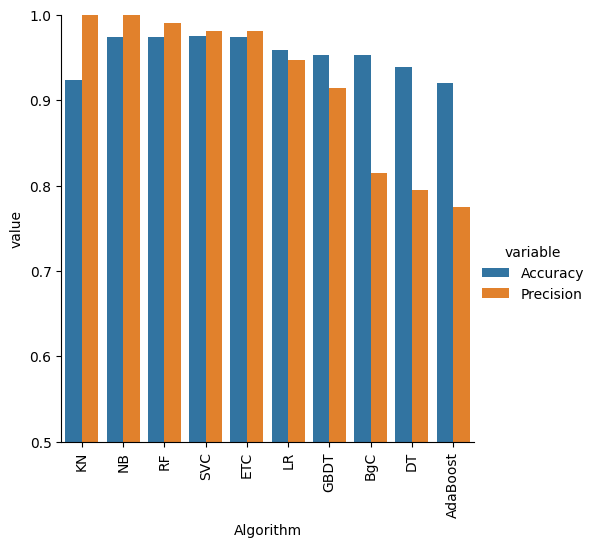

In [27]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

------

## Model Improvement

In [28]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [29]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [30]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,variable,value,Accuracy_max_ft_3000_x,Precision_max_ft_3000_x,Accuracy_max_ft_3000_y,Precision_max_ft_3000_y,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,Accuracy,0.924419,0.924419,1.000000,0.924419,1.000000,0.924419,1.000000
1,NB,Accuracy,0.973837,0.973837,1.000000,0.973837,1.000000,0.973837,1.000000
2,RF,Accuracy,0.974806,0.974806,0.990196,0.974806,0.990196,0.974806,0.990196
3,SVC,Accuracy,0.975775,0.975775,0.980952,0.975775,0.980952,0.975775,0.980952
4,ETC,Accuracy,0.974806,0.974806,0.980769,0.974806,0.980769,0.974806,0.980769
5,LR,Accuracy,0.959302,0.959302,0.946809,0.959302,0.946809,0.959302,0.946809
6,GBDT,Accuracy,0.953488,0.953488,0.914894,0.953488,0.914894,0.953488,0.914894
7,BgC,Accuracy,0.953488,0.953488,0.814516,0.953488,0.814516,0.953488,0.814516
8,DT,Accuracy,0.938953,0.938953,0.794393,0.938953,0.794393,0.938953,0.794393
9,AdaBoost,Accuracy,0.920543,0.920543,0.775000,0.920543,0.775000,0.920543,0.775000


-------

## Saving The best fitted model mnb

In [31]:
import pickle

In [32]:
pickle.dump(tf,open('../ml/vectorizer.pkl','wb'))
pickle.dump(mnb,open('../ml/model.pkl','wb'))